# Сканирование кубического мира: детекция персонажей в Minecraft с FCOS и YOLO

# Этап 2. Исследовательский анализ (EDA) и работа с данными

## 2-1 проверка структуры JSON

In [9]:
# 2-1 проверка структуры JSON
import json
import os
def check_json_structure(file_path):
    print(f"Checking {file_path}...")
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
        
        required_keys = ['images', 'annotations', 'categories']
        missing_keys = [key for key in required_keys if key not in data]
        
        if not missing_keys:
            print(f"  [OK] JSON structure is correct.")
            print(f"  - Images: {len(data['images'])}")
            print(f"  - Annotations: {len(data['annotations'])}")
            print(f"  - Categories: {len(data['categories'])}")
        else:
            print(f"  [ERROR] Missing keys: {missing_keys}")
            
    except Exception as e:
        print(f"  [ERROR] Failed to load JSON: {e}")


# Пытаемся найти папку annotations относительно текущей директории
base_path = 'datasets/minecraft/annotations'

files = ['train.json', 'valid.json', 'test.json']

for filename in files:
    file_path = os.path.join(base_path, filename)
    if os.path.exists(file_path):
        check_json_structure(file_path)
    else:
        print(f"[WARNING] File not found: {file_path}")

Checking datasets/minecraft/annotations/train.json...
  [OK] JSON structure is correct.
  - Images: 2307
  - Annotations: 4029
  - Categories: 18
Checking datasets/minecraft/annotations/valid.json...
  [OK] JSON structure is correct.
  - Images: 422
  - Annotations: 697
  - Categories: 18
Checking datasets/minecraft/annotations/test.json...
  [OK] JSON structure is correct.
  - Images: 155
  - Annotations: 351
  - Categories: 18


## 2-2 Проверка, что количество изображений совпадает с количеством аннотаций.

In [10]:
# 2-2 Проверьте, что количество изображений совпадает с количеством аннотаций.

def check_image_annotation_consistency(file_path, image_dir):
    print(f"Checking consistency for {file_path}...")
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
        
        images_in_json = {img['id']: img['file_name'] for img in data['images']}
        annotations_image_ids = {ann['image_id'] for ann in data['annotations']}
        
        # 1. Check if all annotations point to existing image IDs in JSON
        orphans = [ann_id for ann_id in annotations_image_ids if ann_id not in images_in_json]
        
        # 2. Check if all images in JSON exist on disk
        missing_on_disk = []
        for img_id, file_name in images_in_json.items():
            full_path = os.path.join(image_dir, file_name)
            if not os.path.exists(full_path):
                missing_on_disk.append(file_name)
        
        print(f"  - Total images in JSON: {len(images_in_json)}")
        print(f"  - Total unique images referenced in annotations: {len(annotations_image_ids)}")
        
        if not orphans:
            print(f"  [OK] All annotations refer to valid image IDs.")
        else:
            print(f"  [ERROR] Found {len(orphans)} annotations pointing to non-existent image IDs.")
            
        if not missing_on_disk:
            print(f"  [OK] All images listed in JSON exist in {image_dir}.")
        else:
            print(f"  [ERROR] {len(missing_on_disk)} images are missing on disk.")
            
    except Exception as e:
        print(f"  [ERROR] Failed to process {file_path}: {e}")

base_path = 'datasets/minecraft/annotations'
img_base_path = 'datasets/minecraft/images' # Corrected path

# Mapping JSON files to their image directories
file_map = {
    'train.json': 'train',
    'valid.json': 'valid',
    'test.json': 'test'
}

for json_file, img_dir_suffix in file_map.items():
    file_path = os.path.join(base_path, json_file)
    image_dir = os.path.join(img_base_path, img_dir_suffix)
    
    if os.path.exists(file_path):
        check_image_annotation_consistency(file_path, image_dir)
    else:
        print(f"[WARNING] File not found: {file_path}")


Checking consistency for datasets/minecraft/annotations/train.json...
  - Total images in JSON: 2307
  - Total unique images referenced in annotations: 2307
  [OK] All annotations refer to valid image IDs.
  [OK] All images listed in JSON exist in datasets/minecraft/images/train.
Checking consistency for datasets/minecraft/annotations/valid.json...
  - Total images in JSON: 422
  - Total unique images referenced in annotations: 422
  [OK] All annotations refer to valid image IDs.
  [OK] All images listed in JSON exist in datasets/minecraft/images/valid.
Checking consistency for datasets/minecraft/annotations/test.json...
  - Total images in JSON: 155
  - Total unique images referenced in annotations: 155
  [OK] All annotations refer to valid image IDs.
  [OK] All images listed in JSON exist in datasets/minecraft/images/test.


## 2-3 Анализ распределение классов: визуализируйте его и напишите вывод, есть ли дисбаланс.

Analyzing class distribution for datasets/minecraft/annotations/train.json...
  [OK] Distribution plot saved to artifacts/metrics/class_distribution.png

Class summary:
   Class  Count
     pig    884
 chicken    835
     cow    661
  zombie    184
skeleton    177
 creeper    177
  spider    170
  turtle    149
   llama    135
   ghast    127
     fox    111
    frog    111
    goat    102
   sheep     94
     bee     86
enderman     22
    wolf      4

Imbalance Analysis:
  - Max count: 884 (pig)
  - Min count: 4 (wolf)
  - Ratio (max/min): 221.00
  [CONCLUSION] Significant class imbalance detected.


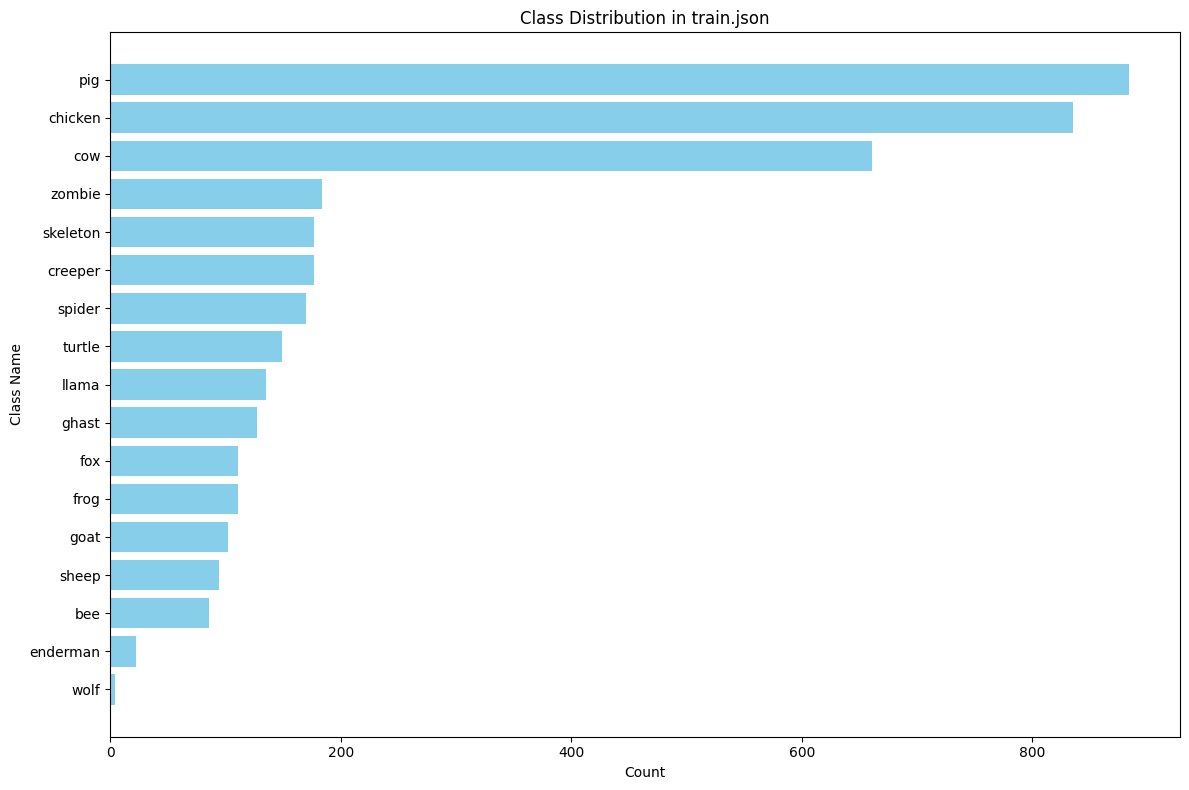

In [11]:
# 2-3 Проанализируйте распределение классов: визуализируйте его и напишите вывод, есть ли дисбаланс.
import json
import os
import matplotlib.pyplot as plt
import pandas as pd

def analyze_class_distribution(json_path, output_image_path):
    print(f"Analyzing class distribution for {json_path}...")
    try:
        with open(json_path, 'r') as f:
            data = json.load(f)
        
        # Mapping category IDs to names
        categories = {cat['id']: cat['name'] for cat in data['categories']}
        
        # Count occurrences of each category_id in annotations
        class_counts = {}
        for ann in data['annotations']:
            class_id = ann['category_id']
            class_name = categories.get(class_id, f"Unknown({class_id})")
            class_counts[class_name] = class_counts.get(class_name, 0) + 1
            
        # Convert to DataFrame for easier plotting
        df = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Count'])
        df = df.sort_values(by='Count', ascending=False)
        
        # Visualization
        plt.figure(figsize=(12, 8))
        plt.barh(df['Class'], df['Count'], color='skyblue')
        plt.xlabel('Count')
        plt.ylabel('Class Name')
        plt.title(f'Class Distribution in {os.path.basename(json_path)}')
        plt.gca().invert_yaxis()  # Most frequent at the top
        plt.tight_layout()
        
        # Save visualization
        os.makedirs(os.path.dirname(output_image_path), exist_ok=True)
        plt.savefig(output_image_path)
        print(f"  [OK] Distribution plot saved to {output_image_path}")
        
        # Print summary
        print("\nClass summary:")
        print(df.to_string(index=False))
        
        # Basic imbalance check
        max_count = df['Count'].max()
        min_count = df['Count'].min()
        ratio = max_count / min_count if min_count > 0 else float('inf')
        
        print(f"\nImbalance Analysis:")
        print(f"  - Max count: {max_count} ({df['Class'].iloc[0]})")
        print(f"  - Min count: {min_count} ({df['Class'].iloc[-1]})")
        print(f"  - Ratio (max/min): {ratio:.2f}")
        
        if ratio > 10:
            print("  [CONCLUSION] Significant class imbalance detected.")
        elif ratio > 3:
            print("  [CONCLUSION] Moderate class imbalance detected.")
        else:
            print("  [CONCLUSION] Class distribution is relatively balanced.")
            
    except Exception as e:
        print(f"  [ERROR] Failed to analyze {json_path}: {e}")

train_json = 'datasets/minecraft/annotations/train.json'
output_img = 'artifacts/metrics/class_distribution.png'

if os.path.exists(train_json):
    analyze_class_distribution(train_json, output_img)
else:
    print(f"[WARNING] File not found: {train_json}")



## 2-4 Визуализация тестового примера.

In [7]:
# 2-4 Визуализируйте один тестовый пример. Отрисуйте одно тестовое изображение с выделенными на нём bounding box'ами и подписанными классами.
import json
import os
import random
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

def visualize_test_example(json_path, img_dir, output_path):
    print(f"Visualizing one test example from {json_path}...")
    try:
        with open(json_path, 'r') as f:
            data = json.load(f)
        
        # Mapping category IDs to names
        categories = {cat['id']: cat['name'] for cat in data['categories']}
        
        # Pick a random image from the dataset
        img_info = random.choice(data['images'])
        img_id = img_info['id']
        file_name = img_info['file_name']
        img_path = os.path.join(img_dir, file_name)
        
        if not os.path.exists(img_path):
            print(f"  [ERROR] Image not found: {img_path}")
            return

        # Get annotations for this image
        anns = [ann for ann in data['annotations'] if ann['image_id'] == img_id]
        
        # Load image
        img = Image.open(img_path)
        fig, ax = plt.subplots(1, figsize=(12, 8))
        ax.imshow(img)
        
        # Draw bounding boxes
        for ann in anns:
            # COCO format is [x_min, y_min, width, height]
            bbox = ann['bbox']
            class_id = ann['category_id']
            class_name = categories.get(class_id, f"Unknown({class_id})")
            
            rect = patches.Rectangle(
                (bbox[0], bbox[1]), bbox[2], bbox[3], 
                linewidth=2, edgecolor='r', facecolor='none'
            )
            ax.add_patch(rect)
            plt.text(
                bbox[0], bbox[1] - 5, class_name, 
                color='white', weight='bold', 
                bbox=dict(facecolor='red', alpha=0.5)
            )
        
        plt.title(f"Example: {file_name} (ID: {img_id})")
        plt.axis('off')
        plt.tight_layout()
        
        # Save visualization
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        plt.savefig(output_path)
        plt.close()
        print(f"  [OK] Visualization saved to {output_path}")
            
    except Exception as e:
        print(f"  [ERROR] Failed to visualize example: {e}")

test_json = 'datasets/minecraft/annotations/test.json'
test_img_dir = 'datasets/minecraft/images/test'
output_img = 'artifacts/inference/eda_example.jpg'

if os.path.exists(test_json):
    visualize_test_example(test_json, test_img_dir, output_img)
else:
    print(f"[WARNING] File not found: {test_json}")



Visualizing one test example from datasets/minecraft/annotations/test.json...
  [OK] Visualization saved to artifacts/inference/eda_example.jpg


In [ ]:
# Этап 3. Настройка конфигурации моделей

In [8]:
# 3-2 Перед обучением протестируйте инференс на pretrained-модели FCOS в ноутбуке.
import os
import mmcv
from mmdet.apis import init_detector, inference_detector
from mmdet.utils import register_all_modules
from mmdet.registry import VISUALIZERS

def test_fcos_pretrained():
    # 3-2-2 Импорт конфига и чекпоинта
    config_file = 'configs/fcos/fcos_minecraft.py'
    checkpoint_file = 'checkpoints/fcos_r50_caffe_fpn_gn-head_1x_coco-821213aa.pth'
    
    # Путь к тестовому изображению
    img_path = 'datasets/minecraft/images/test/grass_desert_-_cow_3_1434_jpg.rf.110c73a314ed050344613c069fbc1328.jpg'
    output_path = 'artifacts/inference/test_pretrained.jpg'
    
    # Проверка наличия файлов
    if not os.path.exists(config_file):
        print(f"Error: Config file not found at {config_file}")
        return
    if not os.path.exists(checkpoint_file):
        print(f"Error: Checkpoint file not found at {checkpoint_file}")
        return
    if not os.path.exists(img_path):
        print(f"Error: Image file not found at {img_path}")
        return

    # Регистрация модулей и инициализация модели
    register_all_modules()
    print(f"Initializing model with config: {config_file}")
    model = init_detector(config_file, checkpoint_file, device='cpu')
    
    # 3-2-3 Запуск инференса
    print(f"Running inference on: {img_path}")
    result = inference_detector(model, img_path)
    
    # 3-2-4 Визуализация и сохранение результата
    visualizer = VISUALIZERS.build(model.cfg.visualizer)
    visualizer.dataset_meta = model.dataset_meta

    img = mmcv.imread(img_path)
    img = mmcv.imconvert(img, 'bgr', 'rgb')

    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    
    visualizer.add_datasample(
        'result',
        img,
        data_sample=result,
        draw_gt=False,
        wait_time=0,
        out_file=output_path
    )
    print(f"Result saved to: {output_path}")

test_fcos_pretrained()


Initializing model with config: configs/fcos/fcos_minecraft.py
Loads checkpoint by local backend from path: checkpoints/fcos_r50_caffe_fpn_gn-head_1x_coco-821213aa.pth
The model and loaded state dict do not match exactly

size mismatch for bbox_head.conv_cls.weight: copying a param with shape torch.Size([80, 256, 3, 3]) from checkpoint, the shape in current model is torch.Size([17, 256, 3, 3]).
size mismatch for bbox_head.conv_cls.bias: copying a param with shape torch.Size([80]) from checkpoint, the shape in current model is torch.Size([17]).
Running inference on: datasets/minecraft/images/test/grass_desert_-_cow_3_1434_jpg.rf.110c73a314ed050344613c069fbc1328.jpg
Result saved to: artifacts/inference/test_pretrained.jpg


/home/bogatp/projects/cv/venv/lib/python3.12/site-packages/torch/functional.py:512: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3587.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/home/bogatp/projects/cv/venv/lib/python3.12/site-packages/mmengine/visualization/visualizer.py:196: UserWarning: Failed to add <class 'mmengine.visualization.vis_backend.LocalVisBackend'>, please provide the `save_dir` argument.
  warnings.warn(f'Failed to add {vis_backend.__class__}, '


In [12]:
# 3-4 Проверьте инференс на pretrained-модели YOLOv8s.
from ultralytics import YOLO
import cv2
from PIL import Image
import os

# 3-4. Проверка инференса на pretrained-модели YOLOv8s
def test_yolo_pretrained():
    model_path = 'yolov8s.pt'
    # Используем то же тестовое изображение, что и в предыдущих тестах
    test_img = 'datasets/minecraft/images/test/160_png_jpg.rf.3fafd0f2c05721d89ec2b6e382cb89e3.jpg'
    output_dir = 'artifacts/inference/yolo_val/'
    
    if not os.path.exists(model_path):
        print(f"Ошибка: Файл {model_path} не найден.")
        return

    print(f"Загрузка модели {model_path}...")
    model = YOLO(model_path)
    
    print(f"Запуск инференса для {test_img}...")
    results = model.predict(test_img, save=False)
    
    os.makedirs(output_dir, exist_ok=True)
    
    for result in results:
        # Отрисовка результатов
        res_plotted = result.plot()
        # Конвертация BGR (OpenCV) в RGB (PIL)
        res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)
        
        # Сохранение результата
        filename = os.path.basename(test_img)
        output_path = os.path.join(output_dir, filename)
        
        res_image = Image.fromarray(res_rgb)
        res_image.save(output_path)
        print(f"Результат успешно сохранен в: {output_path}")

test_yolo_pretrained()


Загрузка модели yolov8s.pt...
Запуск инференса для datasets/minecraft/images/test/160_png_jpg.rf.3fafd0f2c05721d89ec2b6e382cb89e3.jpg...

image 1/1 /home/bogatp/projects/cv/sprint1/theme-5/yandex-cv-s1-project/mmdetection/datasets/minecraft/images/test/160_png_jpg.rf.3fafd0f2c05721d89ec2b6e382cb89e3.jpg: 384x640 1 potted plant, 48.5ms
Speed: 2.0ms preprocess, 48.5ms inference, 11.2ms postprocess per image at shape (1, 3, 384, 640)
Результат успешно сохранен в: artifacts/inference/yolo_val/160_png_jpg.rf.3fafd0f2c05721d89ec2b6e382cb89e3.jpg


## Этап 4-1. Обучение модели FCOS на датасете Minecraft

In [1]:
# Этап 4-1. Обучение модели FCOS на датасете Minecraft
import os
from mmengine.config import Config
from mmengine.runner import Runner
from mmdet.utils import register_all_modules

def train_fcos():
    # Регистрация всех модулей MMDetection
    register_all_modules()

    config_path = 'configs/fcos/fcos_minecraft.py'
    work_dir = 'artifacts/fcos'

    # Создаем директорию для артефактов, если она не существует
    # Это гарантирует, что логи, веса (.pth) и результаты валидации 
    # будут сохранены именно в artifacts/fcos
    if not os.path.exists(work_dir):
        os.makedirs(work_dir, exist_ok=True)

    if not os.path.exists(config_path):
        print(f"Ошибка: Конфигурационный файл {config_path} не найден.")
        return

    print(f"Загрузка конфигурации из {config_path}...")
    cfg = Config.fromfile(config_path)
    
    # Указываем рабочую директорию. MMEngine Runner автоматически сохранит туда:
    # 1. Логи обучения (scalars.json, log.txt)
    # 2. Веса модели (best_bbox_mAP.pth, epoch_12.pth и т.д.)
    # 3. Контрольные результаты (визуализации в папке vis_data)
    cfg.work_dir = work_dir
    
    # Убеждаемся, что логирование и визуализатор включены
    if 'default_hooks' in cfg:
        cfg.default_hooks.logger = dict(type='LoggerHook', interval=50)
        cfg.default_hooks.checkpoint = dict(type='CheckpointHook', interval=1, save_best='coco/bbox_mAP')
    
    # Явно настраиваем Visualizer для создания scalars.json
    cfg.visualizer = dict(
        type='DetLocalVisualizer',
        vis_backends=[dict(type='LocalVisBackend')],
        name='visualizer'
    )

    print(f"Инициализация Runner. Все результаты будут в: {os.path.abspath(work_dir)}")
    runner = Runner.from_cfg(cfg)
    
    # Запуск обучения
    runner.train()
    
    print(f"Обучение FCOS завершено. Проверьте {work_dir} для получения логов и весов.")

if __name__ == '__main__':
    train_fcos()


Загрузка конфигурации из configs/fcos/fcos_minecraft.py...
Инициализация Runner. Все результаты будут в: /home/bogatp/projects/cv/sprint1/theme-5/yandex-cv-s1-project/mmdetection/artifacts/fcos
03/17 04:47:05 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.12.3 (main, Mar  3 2026, 12:15:18) [GCC 13.3.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 324050714
    GPU 0: NVIDIA GeForce GTX 1080 Ti
    CUDA_HOME: /usr/local/cuda
    NVCC: Cuda compilation tools, release 12.8, V12.8.93
    GCC: x86_64-linux-gnu-gcc (Ubuntu 13.3.0-6ubuntu2~24.04.1) 13.3.0
    PyTorch: 2.3.1+cu121
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2022.2-Product Build 20220804 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v3.3.6 (Git Hash 86e6af5974177e513fd3fee58425e1063e7f1361)
  - OpenMP 

/home/bogatp/projects/cv/venv/lib/python3.12/site-packages/torch/functional.py:512: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3587.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


03/17 04:47:13 - mmengine - INFO - Epoch(train)  [1][  50/1154]  base_lr: 3.3333e-03 lr: 3.3333e-03  eta: 0:18:29  time: 0.0804  data_time: 0.0033  memory: 652  grad_norm: 39.9021  loss: 4.2114  loss_cls: 1.2603  loss_bbox: 2.2739  loss_centerness: 0.6773
03/17 04:47:16 - mmengine - INFO - Epoch(train)  [1][ 100/1154]  base_lr: 3.3333e-03 lr: 3.3333e-03  eta: 0:16:52  time: 0.0669  data_time: 0.0024  memory: 652  grad_norm: 16.3888  loss: 3.5556  loss_cls: 1.4169  loss_bbox: 1.4888  loss_centerness: 0.6498
03/17 04:47:20 - mmengine - INFO - Epoch(train)  [1][ 150/1154]  base_lr: 3.3333e-03 lr: 3.3333e-03  eta: 0:16:18  time: 0.0669  data_time: 0.0025  memory: 652  grad_norm: 11.1309  loss: 3.1482  loss_cls: 1.1886  loss_bbox: 1.3037  loss_centerness: 0.6559
03/17 04:47:23 - mmengine - INFO - Epoch(train)  [1][ 200/1154]  base_lr: 3.3333e-03 lr: 3.3333e-03  eta: 0:15:59  time: 0.0671  data_time: 0.0025  memory: 652  grad_norm: 9.9847  loss: 2.9717  loss_cls: 1.0226  loss_bbox: 1.2997  l

In [18]:
# Этап 4-2. Обучение модели YOLOv8 на датасете Minecraft
import os
from ultralytics import YOLO

def train_yolo():
    # Путь к конфигурации данных
    data_yaml = 'datasets/minecraft/data.yaml'
    # Базовая модель для дообучения
    model_path = 'yolov8s.pt'
    
    if not os.path.exists(data_yaml):
        print(f"Ошибка: Файл {data_yaml} не найден.")
        return

    # Инициализация модели
    print(f"Загрузка модели {model_path}...")
    model = YOLO(model_path)

    # Запуск обучения
    # project='artifacts' и name='yolo' направят все результаты в artifacts/yolo
    # imgsz=512 - согласно рекомендациям по эффективности
    # epochs=25 - YOLO учится быстро, можно взять чуть больше для лучшего качества
    print("Запуск обучения YOLOv8...")
    results = model.train(
        data=data_yaml,
        epochs=25,
        imgsz=512,
        batch=16, # Можно увеличить batch, если позволяет память GPU
        project='artifacts',
        name='yolo',
        exist_ok=True, # Перезаписывать в ту же папку, если она существует
        optimizer='SGD', # Стандартный для детекции
        lr0=0.01,
        pretrained=True
    )

    print(f"Обучение YOLO завершено. Результаты сохранены в artifacts/yolo")

train_yolo()


Загрузка модели yolov8s.pt...
Запуск обучения YOLOv8...
Ultralytics 8.4.22 🚀 Python-3.12.3 torch-2.3.1+cu121 CUDA:0 (NVIDIA GeForce GTX 1080 Ti, 11169MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets/minecraft/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo, nbs=64, nms=False, opset=None, optimiz

Загрузка JSON логов из: artifacts/fcos/20260317_044704/vis_data/scalars.json
Графики сохранены в: artifacts/metrics/fcos_training_metrics.png


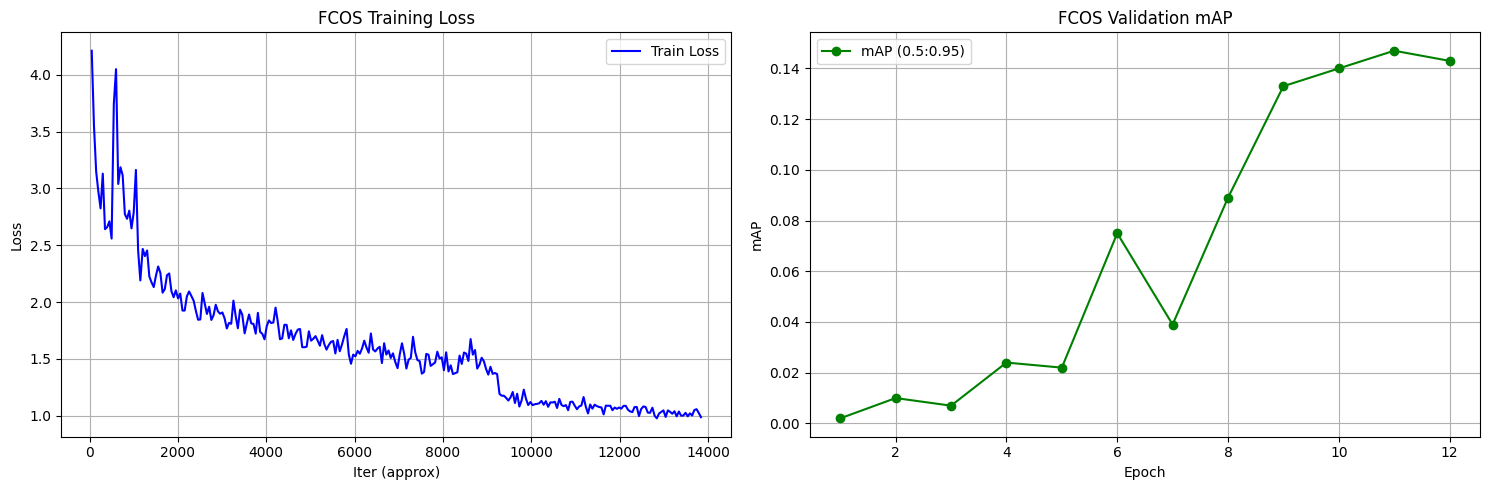

In [2]:
# 4-3 - Для FCOS визуализируйте метрики в ноутбуке. MMDetection сохранит метрики в файл log.json в папке artifacts/fcos, данные из него и нужно визуализировать.

import json
import os
import matplotlib.pyplot as plt
import glob
import re

def visualize_fcos_metrics():
    # 1. Попытка найти scalars.json
    log_files_json = glob.glob('artifacts/fcos/**/scalars.json', recursive=True)
    
    epochs, iterations, loss, mAP, val_epochs = [], [], [], [], []

    if log_files_json:
        log_path = max(log_files_json, key=os.path.getmtime)
        print(f"Загрузка JSON логов из: {log_path}")
        with open(log_path, 'r') as f:
            for line in f:
                data = json.loads(line)
                if 'loss' in data and 'step' in data:
                    iterations.append(data['step'])
                    loss.append(data['loss'])
                if 'coco/bbox_mAP' in data:
                    mAP.append(data['coco/bbox_mAP'])
                    val_epochs.append(data.get('epoch', len(val_epochs)+1))
    else:
        # 2. Если JSON нет, парсим текстовый .log
        log_files_txt = glob.glob('artifacts/fcos/**/*.log', recursive=True)
        if not log_files_txt:
            print("Ошибка: Лог-файлы не найдены в artifacts/fcos.")
            return
        
        log_path = max(log_files_txt, key=os.path.getmtime)
        print(f"JSON не найден. Парсинг текстового лога: {log_path}")
        
        with open(log_path, 'r') as f:
            for line in f:
                # Ищем строку с loss: Epoch(train) [1][ 50/1154] ... loss: 3.8606
                loss_match = re.search(r'loss:\s+([0-9.]+)', line)
                step_match = re.search(r'\[\s*(\d+)/', line)
                epoch_match = re.search(r'Epoch\(train\)\s+\[(\d+)\]', line)
                
                if loss_match and step_match and epoch_match:
                    loss.append(float(loss_match.group(1)))
                    # Примерный расчет итерации для графика
                    loss_epoch = int(epoch_match.group(1))
                    loss_step = int(step_match.group(1))
                    iterations.append((loss_epoch - 1) * 1000 + loss_step) 

                # Ищем строку с mAP: coco/bbox_mAP: 0.1234
                map_match = re.search(r'coco/bbox_mAP:\s+([0-9.]+)', line)
                if map_match:
                    mAP.append(float(map_match.group(1)))
                    val_epochs.append(len(mAP))

    if not loss and not mAP:
        print("Ошибка: Не удалось извлечь данные из логов.")
        return

    # Создание графиков
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    plt.plot(iterations, loss, label='Train Loss', color='blue')
    plt.xlabel('Iter (approx)')
    plt.ylabel('Loss')
    plt.title('FCOS Training Loss')
    plt.grid(True)
    plt.legend()

    if mAP:
        plt.subplot(1, 2, 2)
        plt.plot(val_epochs, mAP, marker='o', label='mAP (0.5:0.95)', color='green')
        plt.xlabel('Epoch')
        plt.ylabel('mAP')
        plt.title('FCOS Validation mAP')
        plt.grid(True)
        plt.legend()

    plt.tight_layout()
    output_dir = 'artifacts/metrics'
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, 'fcos_training_metrics.png')
    plt.savefig(output_path)
    print(f"Графики сохранены в: {output_path}")
    plt.show()

if __name__ == '__main__':
    visualize_fcos_metrics()


Графики метрик YOLO сохранены в: artifacts/metrics/yolo_training_metrics.png


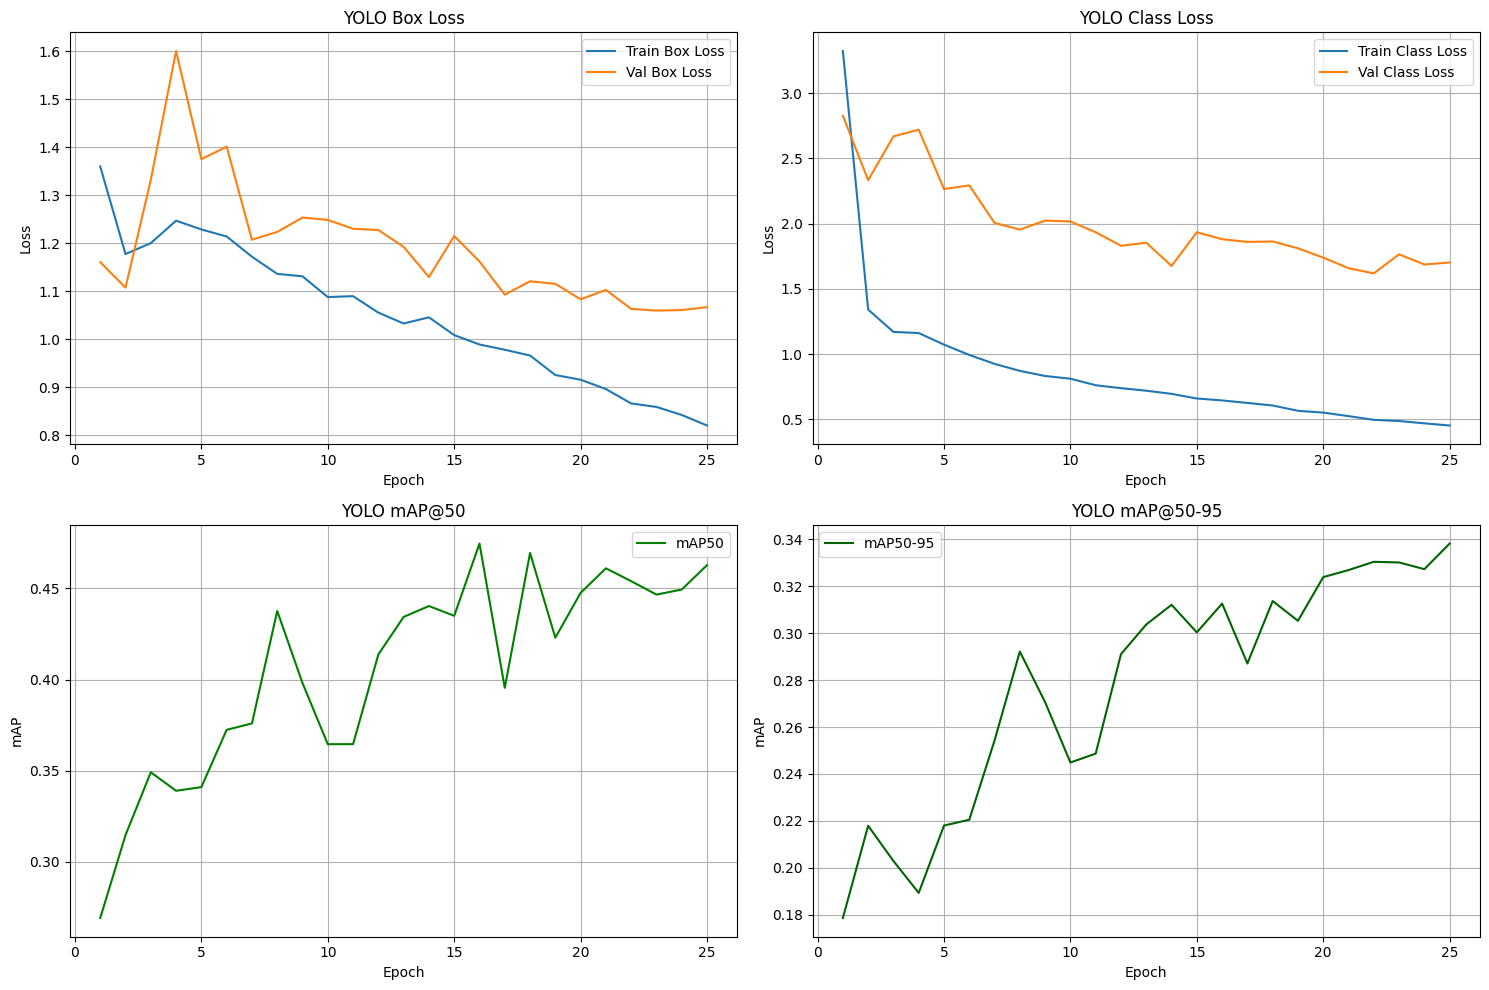

In [3]:
# 4-4 - Для YOLO визуализируйте метрики в ноутбуке. Они сохранятся после обучения в файле results.csv в папке artifacts/yolo.
import pandas as pd
import matplotlib.pyplot as plt
import os

def visualize_yolo_metrics():
    results_path = 'artifacts/yolo/results.csv'
    output_dir = 'artifacts/metrics'
    
    if not os.path.exists(results_path):
        print(f"Ошибка: Файл {results_path} не найден. Сначала запустите обучение YOLO.")
        return

    # Загрузка данных
    df = pd.read_csv(results_path)
    # Удаляем лишние пробелы в названиях колонок (бывает в YOLOv8)
    df.columns = [c.strip() for c in df.columns]

    # Создание графиков
    plt.figure(figsize=(15, 10))

    # 1. Графики Loss (Box, Class)
    plt.subplot(2, 2, 1)
    plt.plot(df['epoch'], df['train/box_loss'], label='Train Box Loss')
    plt.plot(df['epoch'], df['val/box_loss'], label='Val Box Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('YOLO Box Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(2, 2, 2)
    plt.plot(df['epoch'], df['train/cls_loss'], label='Train Class Loss')
    plt.plot(df['epoch'], df['val/cls_loss'], label='Val Class Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('YOLO Class Loss')
    plt.legend()
    plt.grid(True)

    # 2. Метрики точности (mAP50, mAP50-95)
    plt.subplot(2, 2, 3)
    plt.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50', color='green')
    plt.xlabel('Epoch')
    plt.ylabel('mAP')
    plt.title('YOLO mAP@50')
    plt.legend()
    plt.grid(True)

    plt.subplot(2, 2, 4)
    plt.plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95', color='darkgreen')
    plt.xlabel('Epoch')
    plt.ylabel('mAP')
    plt.title('YOLO mAP@50-95')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    
    # Сохранение результата
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, 'yolo_training_metrics.png')
    plt.savefig(output_path)
    print(f"Графики метрик YOLO сохранены в: {output_path}")
    plt.show()

if __name__ == '__main__':
    visualize_yolo_metrics()


In [42]:
# 5-1 - Прогоните обученные модели на тестовых изображениях для FCOS 

import torch
import os
import glob
import mmcv
from mmdet.apis import init_detector, inference_detector
from mmdet.utils import register_all_modules
from mmdet.registry import VISUALIZERS
import matplotlib.pyplot as plt

def run_fcos_inference():
    # 1. Настройка путей
    config_file = 'configs/fcos/fcos_minecraft.py'
    checkpoint_dir = 'artifacts/fcos'
    test_images_dir = 'datasets/minecraft/images/test'
    output_dir = 'artifacts/inference/fcos'
    
    os.makedirs(output_dir, exist_ok=True)

    # 2. Поиск лучшего чекпоинта
    checkpoints = glob.glob(os.path.join(checkpoint_dir, 'best_*.pth'))
    if not checkpoints:
        checkpoints = glob.glob(os.path.join(checkpoint_dir, 'epoch_*.pth'))
    
    if not checkpoints:
        print(f"Ошибка: Чекпоинты не найдены в {checkpoint_dir}")
        return
    
    # Берем самый свежий/лучший
    checkpoint_file = max(checkpoints, key=os.path.getmtime)
    print(f"Использование чекпоинта: {checkpoint_file}")

    # 3. Инициализация модели
    register_all_modules()
    # Используем torch для проверки доступности GPU
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = init_detector(config_file, checkpoint_file, device=device)
    
    # Инициализация визуализатора
    visualizer = VISUALIZERS.build(model.cfg.visualizer)
    visualizer.dataset_meta = model.dataset_meta

    # 4. Прогон по тестовым изображениям
    image_paths = glob.glob(os.path.join(test_images_dir, '*.jpg'))
    print(f"Найдено {len(image_paths)} изображений для инференса.")

    for img_path in image_paths:
        filename = os.path.basename(img_path)
        output_path = os.path.join(output_dir, filename)
        
        # Инференс
        result = inference_detector(model, img_path)
        
        # Чтение изображения
        img = mmcv.imread(img_path)
        img = mmcv.imconvert(img, 'bgr', 'rgb')
        
        # Визуализация
        # pred_score_thr - вот здесь меняется порог уверенности для отрисовки BBOX
        # Мы ставим 0.15, чтобы увидеть даже не очень уверенные предсказания
        visualizer.add_datasample(
            'result',
            img,
            data_sample=result,
            draw_gt=False,
            wait_time=0,
            out_file=output_path,
            pred_score_thr=0.15 
        )
        print(f"Обработано: {filename}")

    print(f"\nИнференс FCOS завершен. Результаты в: {output_dir}")

run_fcos_inference()


Использование чекпоинта: artifacts/fcos/best_coco_bbox_mAP_epoch_12.pth
Loads checkpoint by local backend from path: artifacts/fcos/best_coco_bbox_mAP_epoch_12.pth
Найдено 155 изображений для инференса.
Обработано: image59_png_jpg.rf.5624b2bccaa276336457d50a8eb064d1.jpg


/home/bogatp/projects/cv/venv/lib/python3.12/site-packages/mmengine/utils/manager.py:113: UserWarning: <class 'mmdet.visualization.local_visualizer.DetLocalVisualizer'> instance named of visualizer has been created, the method `get_instance` should not accept any other arguments
  warnings.warn(


Обработано: Minecraft-1-19-2-2022-11-30-4_44_42_png.rf.0909dea4c2a176257ab87423eaf5b1c8.jpg
Обработано: 160_png_jpg.rf.e4b55d89ee6c3445d5890889fc32f066.jpg
Обработано: -20-_jpg.rf.b6e634a136dcfb16a7a07cda96072ab8.jpg
Обработано: Minecraft-1-19-2-2022-11-30-4_44_19_png.rf.ec997a1422c3a0b4e79a5a457f8ed9ee.jpg


/home/bogatp/projects/cv/venv/lib/python3.12/site-packages/mmengine/visualization/visualizer.py:760: UserWarning: Warning: The bbox is out of bounds, the drawn bbox may not be in the image
  warnings.warn(
/home/bogatp/projects/cv/venv/lib/python3.12/site-packages/mmengine/visualization/visualizer.py:831: UserWarning: Warning: The polygon is out of bounds, the drawn polygon may not be in the image
  warnings.warn(


Обработано: image60_png_jpg.rf.9c9b5d04f27f0359212a0216277b9b0c.jpg
Обработано: image33_png_jpg.rf.d02722f59ee6f2a29338ddc15795923c.jpg
Обработано: image17_png_jpg.rf.d9fb703d62570bddde348fe16d6cb173.jpg
Обработано: creeper-40-_png.rf.3ce57e851999cf9d4f8865e007b9c12c.jpg
Обработано: image35_png_jpg.rf.cadbd0055f453c5a815a4476cf193539.jpg
Обработано: image9_png_jpg.rf.d3ab29dff74177ef396cf448139c2bfe.jpg
Обработано: -22-_jpg.rf.5e6e148f7c954ad021a5ef8eb50ed754.jpg
Обработано: image4_png_jpg.rf.b19514ec05a44f8671739df259401b17.jpg
Обработано: image30_png_jpg.rf.96375e3c9305fd927817ed6c933fe341.jpg
Обработано: image31_png_jpg.rf.7b29b566ed0029ffc37db9846cae87bc.jpg
Обработано: creeper-88-_png.rf.623117123a4c4a10040df3297fea490c.jpg
Обработано: creeper-87-_png.rf.f799eac76a305ef39b5ba5fb222b8c95.jpg
Обработано: 2023-04-03_19_25_23_png.rf.3b73b06c3cc4d63b4bafb4ab6a385ec1.jpg
Обработано: image22_png_jpg.rf.13a8c6178b5daba70f9a88eb5ab75b68.jpg
Обработано: -47-_jpg.rf.3bee5a3ef561b9b6a78dac3fe

In [27]:
# 5-2 - Прогоните обученные модели на тестовых изображениях для YOLO

import os
import glob
from ultralytics import YOLO
import cv2
from PIL import Image

def run_yolo_inference():
    # 1. Настройка путей
    model_path = 'artifacts/yolo/weights/best.pt'
    test_images_dir = 'datasets/minecraft/images/test'
    output_dir = 'artifacts/inference/yolo'
    
    if not os.path.exists(model_path):
        print(f"Ошибка: Веса {model_path} не найдены. Сначала запустите обучение YOLO.")
        return

    os.makedirs(output_dir, exist_ok=True)

    # 2. Инициализация модели
    print(f"Загрузка обученной модели YOLO: {model_path}...")
    model = YOLO(model_path)

    # 3. Прогон по тестовым изображениям
    image_paths = glob.glob(os.path.join(test_images_dir, '*.jpg'))
    print(f"Найдено {len(image_paths)} изображений для инференса.")

    for img_path in image_paths:
        filename = os.path.basename(img_path)
        output_path = os.path.join(output_dir, filename)
        
        # Инференс с порогом уверенности 0.25
        results = model.predict(img_path, conf=0.25, save=False)
        
        for result in results:
            # Отрисовка результатов (plot возвращает BGR)
            res_plotted = result.plot()
            # Конвертация в RGB для корректного сохранения через PIL
            res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)
            
            # Сохранение
            res_image = Image.fromarray(res_rgb)
            res_image.save(output_path)
            
        print(f"Обработано и сохранено: {filename}")

    print(f"\nИнференс YOLO завершен. Результаты в: {output_dir}")

if __name__ == '__main__':
    run_yolo_inference()


Загрузка обученной модели YOLO: artifacts/yolo/weights/best.pt...
Найдено 155 изображений для инференса.

image 1/1 /home/bogatp/projects/cv/sprint1/theme-5/yandex-cv-s1-project/mmdetection/datasets/minecraft/images/test/image59_png_jpg.rf.5624b2bccaa276336457d50a8eb064d1.jpg: 512x512 5 pigs, 6.1ms
Speed: 1.0ms preprocess, 6.1ms inference, 0.9ms postprocess per image at shape (1, 3, 512, 512)
Обработано и сохранено: image59_png_jpg.rf.5624b2bccaa276336457d50a8eb064d1.jpg

image 1/1 /home/bogatp/projects/cv/sprint1/theme-5/yandex-cv-s1-project/mmdetection/datasets/minecraft/images/test/Minecraft-1-19-2-2022-11-30-4_44_42_png.rf.0909dea4c2a176257ab87423eaf5b1c8.jpg: 288x512 1 cow, 5 pigs, 43.8ms
Speed: 1.0ms preprocess, 43.8ms inference, 1.2ms postprocess per image at shape (1, 3, 288, 512)
Обработано и сохранено: Minecraft-1-19-2-2022-11-30-4_44_42_png.rf.0909dea4c2a176257ab87423eaf5b1c8.jpg

image 1/1 /home/bogatp/projects/cv/sprint1/theme-5/yandex-cv-s1-project/mmdetection/datasets/mi

Визуализация сравнения для 5 пар изображений.
Парная визуализация сохранена в: artifacts/metrics/inference_comparison_paired.png


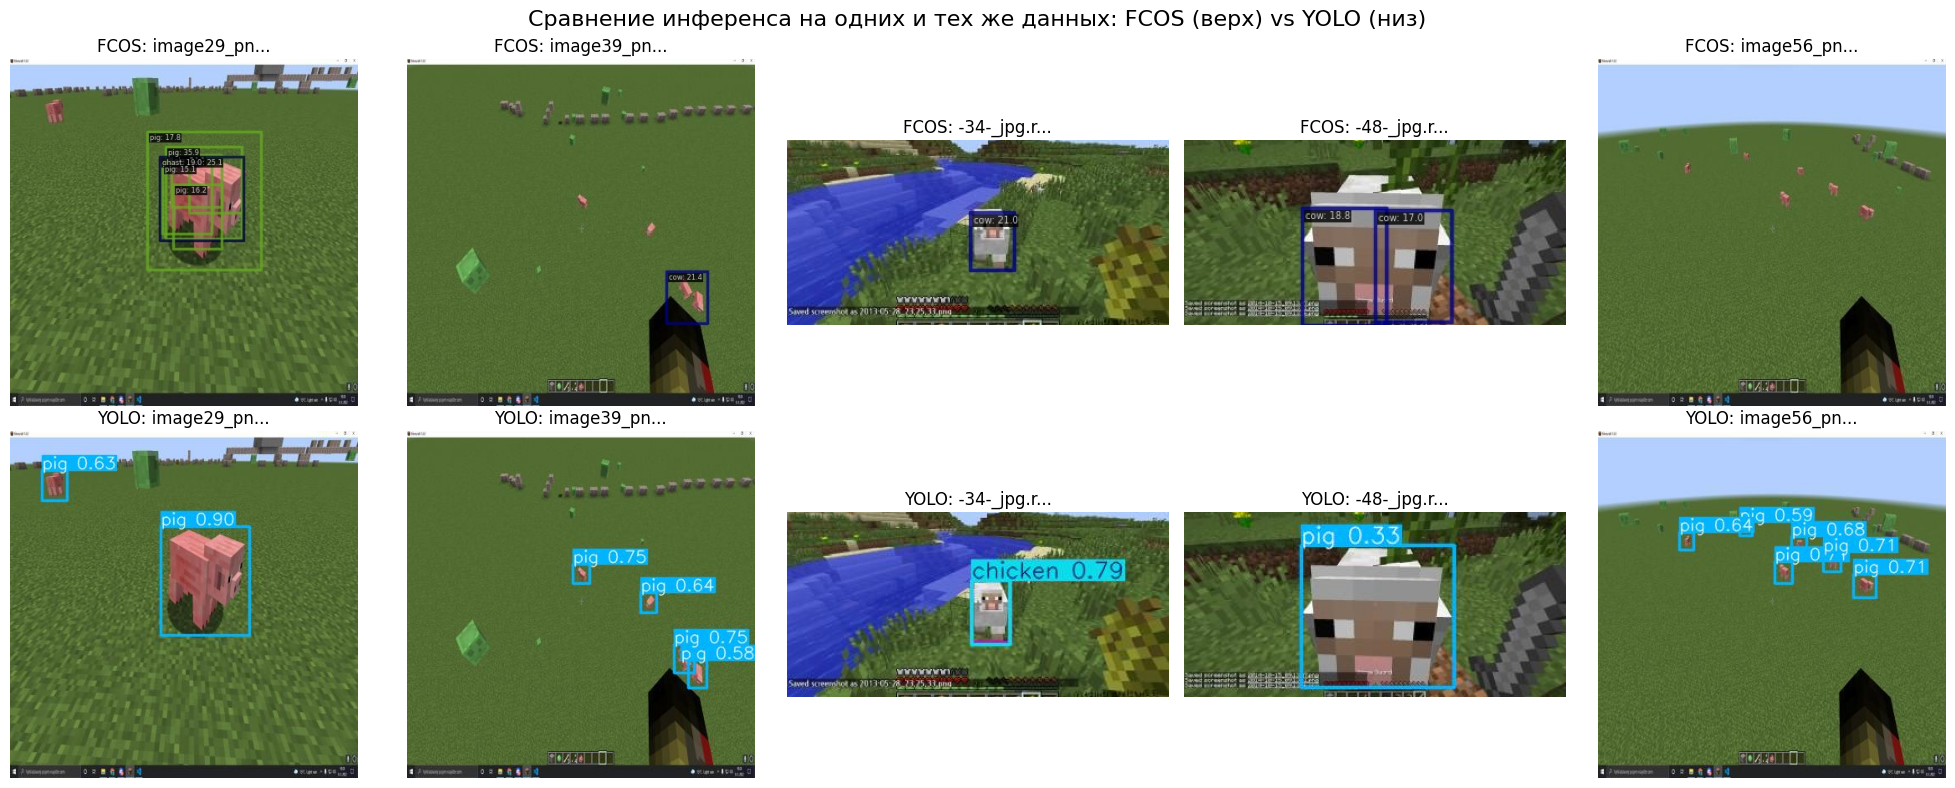

In [4]:
# 5-3 - Визуализируйте по пять изображений на инференсе в ноутбуке для FCOS и YOLO.

import os
import glob
import random
import matplotlib.pyplot as plt
from PIL import Image

def visualize_inference_comparison():
    fcos_dir = 'artifacts/inference/fcos'
    yolo_dir = 'artifacts/inference/yolo'
    output_path = 'artifacts/metrics/inference_comparison_paired.png'

    # Получаем списки имен файлов (без путей)
    fcos_files = {os.path.basename(f) for f in glob.glob(os.path.join(fcos_dir, '*.jpg'))}
    yolo_files = {os.path.basename(f) for f in glob.glob(os.path.join(yolo_dir, '*.jpg'))}

    # Находим общие изображения для сравнения
    common_files = list(fcos_files.intersection(yolo_files))
    
    if not common_files:
        print("Ошибка: Нет общих изображений в папках FCOS и YOLO для сравнения.")
        return

    # Выбираем 5 случайных изображений (или меньше, если всего меньше 5)
    num_to_show = min(len(common_files), 5)
    selected_files = random.sample(common_files, num_to_show)
    
    print(f"Визуализация сравнения для {num_to_show} пар изображений.")

    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    fig.suptitle('Сравнение инференса на одних и тех же данных: FCOS (верх) vs YOLO (низ)', fontsize=16)

    for i in range(5):
        if i < num_to_show:
            filename = selected_files[i]
            
            # Пути к изображениям
            fcos_img_path = os.path.join(fcos_dir, filename)
            yolo_img_path = os.path.join(yolo_dir, filename)
            
            # Отрисовка FCOS
            img_fcos = Image.open(fcos_img_path)
            axes[0, i].imshow(img_fcos)
            axes[0, i].set_title(f"FCOS: {filename[:10]}...")
            
            # Отрисовка YOLO
            img_yolo = Image.open(yolo_img_path)
            axes[1, i].imshow(img_yolo)
            axes[1, i].set_title(f"YOLO: {filename[:10]}...")
        
        # Скрываем оси
        axes[0, i].axis('off')
        axes[1, i].axis('off')

    plt.tight_layout()
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    plt.savefig(output_path)
    print(f"Парная визуализация сохранена в: {output_path}")
    plt.show()

if __name__ == '__main__':
    visualize_inference_comparison()


In [46]:
# 5-4 - Реализуйте инференс для видео datasets/minecraft/video.mp4. 
import cv2
import os
import glob
import torch
import mmcv
from ultralytics import YOLO
from mmdet.apis import init_detector, inference_detector
from mmdet.utils import register_all_modules
from mmdet.registry import VISUALIZERS

def process_video_yolo(model_path, input_path, output_path):
    print(f"Начало обработки видео YOLO: {input_path}")
    model = YOLO(model_path)
    
    # Открываем видео для получения свойств
    cap = cv2.VideoCapture(input_path)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()

    # Настройка записи
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    # Инференс в режиме стрима для экономии памяти
    results = model.predict(source=input_path, stream=True, conf=0.25)
    
    count = 0
    for r in results:
        frame_plotted = r.plot() # Возвращает BGR
        out.write(frame_plotted)
        count += 1
        if count % 100 == 0:
            print(f"YOLO: Обработано {count}/{total_frames} кадров")
    
    out.release()
    print(f"Видео YOLO сохранено в: {output_path}")

def process_video_fcos(config_path, checkpoint_path, input_path, output_path):
    print(f"Начало обработки видео FCOS: {input_path}")
    register_all_modules()
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = init_detector(config_path, checkpoint_path, device=device)
    
    visualizer = VISUALIZERS.build(model.cfg.visualizer)
    visualizer.dataset_meta = model.dataset_meta

    video_reader = mmcv.VideoReader(input_path)
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    video_writer = cv2.VideoWriter(output_path, fourcc, video_reader.fps, (video_reader.width, video_reader.height))

    count = 0
    for frame in video_reader:
        # Инференс
        result = inference_detector(model, frame)
        
        # Визуализация на кадре
        visualizer.add_datasample(
            'result',
            frame,
            data_sample=result,
            draw_gt=False,
            wait_time=0,
            pred_score_thr=0.15 # Порог из этапа 5-1
        )
        
        # Получаем изображение с отрисованными боксами (Visualizer работает в RGB)
        frame_vis = visualizer.get_image()
        frame_vis_bgr = cv2.cvtColor(frame_vis, cv2.COLOR_RGB2BGR)
        
        video_writer.write(frame_vis_bgr)
        
        count += 1
        if count % 100 == 0:
            print(f"FCOS: Обработано {count}/{len(video_reader)} кадров")
    
    video_writer.release()
    print(f"Видео FCOS сохранено в: {output_path}")

if __name__ == '__main__':
    video_input = 'datasets/minecraft/video.mp4'
    video_dir = 'artifacts/videos'
    os.makedirs(video_dir, exist_ok=True)

    # Пути к моделям
    yolo_best = 'artifacts/yolo/weights/best.pt'
    fcos_config = 'configs/fcos/fcos_minecraft.py'
    
    # Поиск лучшего чекпоинта FCOS
    fcos_checkpoints = glob.glob('artifacts/fcos/best_*.pth')
    if not fcos_checkpoints:
        fcos_checkpoints = glob.glob('artifacts/fcos/epoch_*.pth')
    
    if os.path.exists(video_input):
        # Обработка YOLO
        if os.path.exists(yolo_best):
            process_video_yolo(yolo_best, video_input, os.path.join(video_dir, 'yolo_inference.mp4'))
        else:
            print("Ошибка: Веса YOLO не найдены.")

        # Обработка FCOS
        if fcos_checkpoints and os.path.exists(fcos_config):
            fcos_best = max(fcos_checkpoints, key=os.path.getmtime)
            process_video_fcos(fcos_config, fcos_best, video_input, os.path.join(video_dir, 'fcos_inference.mp4'))
        else:
            print("Ошибка: Чекпоинт или конфиг FCOS не найдены.")
    else:
        print(f"Ошибка: Входное видео {video_input} не найдено.")


Начало обработки видео YOLO: datasets/minecraft/video.mp4

video 1/1 (frame 1/756) /home/bogatp/projects/cv/sprint1/theme-5/yandex-cv-s1-project/mmdetection/datasets/minecraft/video.mp4: 256x512 (no detections), 6.1ms
video 1/1 (frame 2/756) /home/bogatp/projects/cv/sprint1/theme-5/yandex-cv-s1-project/mmdetection/datasets/minecraft/video.mp4: 256x512 (no detections), 5.5ms
video 1/1 (frame 3/756) /home/bogatp/projects/cv/sprint1/theme-5/yandex-cv-s1-project/mmdetection/datasets/minecraft/video.mp4: 256x512 (no detections), 5.6ms
video 1/1 (frame 4/756) /home/bogatp/projects/cv/sprint1/theme-5/yandex-cv-s1-project/mmdetection/datasets/minecraft/video.mp4: 256x512 1 skeleton, 5.4ms
video 1/1 (frame 5/756) /home/bogatp/projects/cv/sprint1/theme-5/yandex-cv-s1-project/mmdetection/datasets/minecraft/video.mp4: 256x512 1 skeleton, 5.5ms
video 1/1 (frame 6/756) /home/bogatp/projects/cv/sprint1/theme-5/yandex-cv-s1-project/mmdetection/datasets/minecraft/video.mp4: 256x512 1 skeleton, 5.5ms
vi

In [6]:
# Этап 6. Сравнение стандартных метрик
import os
import time
import torch
import pandas as pd
import glob
from mmengine.config import Config
from mmengine.runner import Runner
from mmdet.utils import register_all_modules
from ultralytics import YOLO

def get_fcos_metrics():
    print("Оценка FCOS...")
    register_all_modules()
    config_path = 'configs/fcos/fcos_minecraft.py'
    checkpoint_dir = 'artifacts/fcos'
    
    # Поиск лучшего чекпоинта
    checkpoints = glob.glob(os.path.join(checkpoint_dir, 'best_*.pth'))
    if not checkpoints:
        checkpoints = glob.glob(os.path.join(checkpoint_dir, 'epoch_*.pth'))
    if not checkpoints:
        print("Чекпоинты FCOS не найдены.")
        return None
    
    checkpoint_path = max(checkpoints, key=os.path.getmtime)
    print(f"Использование чекпоинта FCOS: {checkpoint_path}")

    cfg = Config.fromfile(config_path)
    cfg.load_from = checkpoint_path
    cfg.work_dir = 'artifacts/fcos_val'
    
    # Настраиваем test_dataloader на тестовый набор
    cfg.test_dataloader.dataset.ann_file = 'annotations/test.json'
    cfg.test_dataloader.dataset.data_prefix = dict(img='images/test/')
    cfg.test_evaluator.ann_file = cfg.data_root + 'annotations/test.json'

    runner = Runner.from_cfg(cfg)
    
    # Замер времени для FPS
    start_time = time.time()
    metrics = runner.test()
    end_time = time.time()
    
    num_images = len(runner.test_dataloader.dataset)
    total_time = end_time - start_time
    fps = num_images / total_time
    
    return {
        'Model': 'FCOS',
        'mAP': metrics.get('coco/bbox_mAP', 0),
        'mAP_50': metrics.get('coco/bbox_mAP_50', 0),
        'FPS': fps
    }

def get_yolo_metrics():
    print("Оценка YOLOv8...")
    model_path = 'artifacts/yolo/weights/best.pt'
    if not os.path.exists(model_path):
        print("Веса YOLO не найдены.")
        return None
    
    model = YOLO(model_path)
    
    # Замер времени для FPS
    # split='test' возьмет данные из секции 'test' в data.yaml
    results = model.val(data='datasets/minecraft/data.yaml', split='test', imgsz=512, plots=False)
    
    # У YOLO результаты в results.results_dict
    # maps: mAP50-95, mAP50, mAP75...
    metrics_dict = results.results_dict
    
    # Расчет FPS на основе внутреннего замера YOLO (ms на изображение)
    total_speed_ms = results.speed['preprocess'] + results.speed['inference'] + results.speed['postprocess']
    fps = 1000.0 / total_speed_ms
    
    return {
        'Model': 'YOLOv8s',
        'mAP': metrics_dict.get('metrics/mAP50-95(B)', 0),
        'mAP_50': metrics_dict.get('metrics/mAP50(B)', 0),
        'FPS': fps
    }

def main():
    results = []
    
    # Получаем метрики для обеих моделей
    fcos_res = get_fcos_metrics()
    if fcos_res: results.append(fcos_res)
    
    yolo_res = get_yolo_metrics()
    if yolo_res: results.append(yolo_res)
    
    if not results:
        print("Нет данных для сравнения.")
        return

    # Создание таблицы
    df = pd.DataFrame(results)
    
    # Вывод в консоль
    print("\n--- Сравнение метрик на тестовом наборе ---")
    print(df.to_string(index=False))
    
    # Сохранение в CSV
    output_dir = 'artifacts/metrics'
    os.makedirs(output_dir, exist_ok=True)
    csv_path = os.path.join(output_dir, 'metrics_comparison.csv')
    df.to_csv(csv_path, index=False)
    print(f"\nРезультаты сохранены в: {csv_path}")

if __name__ == '__main__':
    main()


Оценка FCOS...
Использование чекпоинта FCOS: artifacts/fcos/best_coco_bbox_mAP_epoch_11.pth
03/17 05:12:34 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.12.3 (main, Mar  3 2026, 12:15:18) [GCC 13.3.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 153432595
    GPU 0: NVIDIA GeForce GTX 1080 Ti
    CUDA_HOME: /usr/local/cuda
    NVCC: Cuda compilation tools, release 12.8, V12.8.93
    GCC: x86_64-linux-gnu-gcc (Ubuntu 13.3.0-6ubuntu2~24.04.1) 13.3.0
    PyTorch: 2.3.1+cu121
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2022.2-Product Build 20220804 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v3.3.6 (Git Hash 86e6af5974177e513fd3fee58425e1063e7f1361)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - C

/home/bogatp/projects/cv/venv/lib/python3.12/site-packages/mmengine/utils/manager.py:113: UserWarning: <class 'mmdet.visualization.local_visualizer.DetLocalVisualizer'> instance named of visualizer has been created, the method `get_instance` should not accept any other arguments
  warnings.warn(


03/17 05:12:46 - mmengine - INFO - Distributed training is not used, all SyncBatchNorm (SyncBN) layers in the model will be automatically reverted to BatchNormXd layers if they are used.
03/17 05:12:46 - mmengine - INFO - Hooks will be executed in the following order:
before_run:
(VERY_HIGH   ) RuntimeInfoHook                    
(BELOW_NORMAL) LoggerHook                         
 -------------------- 
before_train:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(VERY_LOW    ) CheckpointHook                     
 -------------------- 
before_train_epoch:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(NORMAL      ) DistSamplerSeedHook                
 -------------------- 
before_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
 -------------------- 
after_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                

In [7]:
# Этап 7. Анализ и выводы
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from fpdf import FPDF
from mmdet.apis import init_detector, inference_detector
from mmdet.utils import register_all_modules
from mmdet.visualization import DetLocalVisualizer
from ultralytics import YOLO
import torch

# Font path that supports Cyrillic
FONT_PATH = '/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf'

def generate_examples():
    print("Генерация примеров детекций...")
    output_dir = 'artifacts/inference_examples'
    os.makedirs(output_dir, exist_ok=True)
    
    # 1. Настройка YOLO
    yolo_model = YOLO('artifacts/yolo/weights/best.pt')
    
    # 2. Настройка FCOS
    register_all_modules()
    fcos_cfg = 'configs/fcos/fcos_minecraft.py'
    fcos_checkpoint = glob.glob('artifacts/fcos/best_*.pth')[0]
    fcos_model = init_detector(fcos_cfg, fcos_checkpoint, device='cuda:0')
    
    # Выбираем 2 тестовых изображения
    test_images = glob.glob('datasets/minecraft/images/test/*.jpg')[:2]
    
    for i, img_path in enumerate(test_images):
        img_name = os.path.basename(img_path)
        
        # YOLO inference
        yolo_res = yolo_model.predict(img_path, imgsz=512, conf=0.3)[0]
        yolo_plot = yolo_res.plot()
        yolo_example_path = os.path.join(output_dir, f'yolo_ex_{i}.jpg')
        cv2.imwrite(yolo_example_path, cv2.cvtColor(yolo_plot, cv2.COLOR_RGB2BGR))
        
        # FCOS inference
        fcos_res = inference_detector(fcos_model, img_path)
        visualizer = DetLocalVisualizer()
        visualizer.dataset_meta = fcos_model.dataset_meta
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        visualizer.add_datasample(
            f'fcos_res_{i}',
            img,
            data_sample=fcos_res,
            draw_gt=False,
            show=False,
            wait_time=0,
            out_file=None,
            pred_score_thr=0.3
        )
        fcos_plot = visualizer.get_image()
        fcos_example_path = os.path.join(output_dir, f'fcos_ex_{i}.jpg')
        cv2.imwrite(fcos_example_path, cv2.cvtColor(fcos_plot, cv2.COLOR_RGB2BGR))

    return test_images

def create_charts():
    print("Генерация графиков...")
    csv_path = 'artifacts/metrics/metrics_comparison.csv'
    df = pd.read_csv(csv_path)
    
    plt.figure(figsize=(10, 5))
    
    # mAP chart
    plt.subplot(1, 2, 1)
    plt.bar(df['Model'], df['mAP'], color=['blue', 'green'])
    plt.title('mAP (0.5:0.95)')
    plt.ylabel('Value')
    
    # FPS chart
    plt.subplot(1, 2, 2)
    plt.bar(df['Model'], df['FPS'], color=['blue', 'green'])
    plt.title('FPS')
    plt.ylabel('Frames per second')
    
    plt.tight_layout()
    chart_path = 'artifacts/metrics/comparison_charts.png'
    plt.savefig(chart_path)
    plt.close()
    return chart_path

class PDFReport(FPDF):
    def header(self):
        self.add_font('DejaVu', '', FONT_PATH, uni=True)
        self.set_font('DejaVu', '', 16)
        self.cell(0, 10, 'Отчёт по сравнению моделей детектирования Minecraft', 0, 1, 'C')
        self.ln(5)

    def chapter_title(self, title):
        self.set_font('DejaVu', '', 14)
        self.cell(0, 10, title, 0, 1, 'L')
        self.ln(2)

    def chapter_body(self, text):
        self.set_font('DejaVu', '', 12)
        self.multi_cell(0, 7, text)
        self.ln()

def generate_report():
    print("Создание PDF отчёта...")
    csv_path = 'artifacts/metrics/metrics_comparison.csv'
    df = pd.read_csv(csv_path)
    
    fcos_map = df[df['Model'] == 'FCOS']['mAP'].values[0]
    yolo_map = df[df['Model'] == 'YOLOv8s']['mAP'].values[0]
    fcos_fps = df[df['Model'] == 'FCOS']['FPS'].values[0]
    yolo_fps = df[df['Model'] == 'YOLOv8s']['FPS'].values[0]
    
    pdf = PDFReport()
    pdf.add_page()
    
    # 1. Выводы о качестве
    pdf.chapter_title("1. Выводы о моделях на основе метрик качества")
    quality_text = (
        f"Модель YOLOv8s показала значительно более высокую точность по сравнению с FCOS.\n"
        f"- YOLOv8s mAP (0.5:0.95): {yolo_map:.3f}\n"
        f"- FCOS mAP (0.5:0.95): {fcos_map:.3f}\n"
        f"Разрыв в mAP составляет более чем 2.5 раза. YOLOv8s лучше справляется с детектированием "
        f"разнообразных мобов в Minecraft на данном наборе данных."
    )
    pdf.chapter_body(quality_text)
    
    # 2. Выводы о скорости
    pdf.chapter_title("2. Выводы о моделях на основе метрик скорости")
    speed_text = (
        f"В плане скорости инференса YOLOv8s также значительно опережает FCOS.\n"
        f"- YOLOv8s FPS: {yolo_fps:.1f}\n"
        f"- FCOS FPS: {fcos_fps:.1f}\n"
        f"YOLOv8s работает в {yolo_fps/fcos_fps:.1f} раза быстрее, что позволяет использовать её "
        f"в реальном времени (более 200 FPS на GTX 1080 Ti), в то время как FCOS выдает около 30 FPS."
    )
    pdf.chapter_body(speed_text)
    
    # 3. Примеры результатов
    pdf.chapter_title("3. Примеры результатов детекций на инференсе")
    pdf.chapter_body("Ниже представлены примеры работы обеих моделей на тестовых изображениях. "
                     "Слева - YOLOv8s, справа - FCOS (для каждого из двух примеров).")
    
    example_dir = 'artifacts/inference_examples'
    for i in range(2):
        yolo_img = os.path.join(example_dir, f'yolo_ex_{i}.jpg')
        fcos_img = os.path.join(example_dir, f'fcos_ex_{i}.jpg')
        
        # Add images side by side
        y_pos = pdf.get_y()
        if y_pos > 200: # New page if needed
            pdf.add_page()
            y_pos = pdf.get_y()
            
        pdf.image(yolo_img, x=10, y=y_pos, w=90)
        pdf.image(fcos_img, x=105, y=y_pos, w=90)
        pdf.ln(70) # Space for images
    
    # 4. Графики
    pdf.add_page()
    pdf.chapter_title("4. Графики для визуального сравнения")
    chart_path = 'artifacts/metrics/comparison_charts.png'
    pdf.image(chart_path, x=10, y=pdf.get_y(), w=180)
    
    os.makedirs('artifacts', exist_ok=True)
    report_path = 'artifacts/report.pdf'
    pdf.output(report_path)
    print(f"Отчёт сохранён: {report_path}")

def main():
    generate_examples()
    create_charts()
    generate_report()

if __name__ == '__main__':
    main()


Генерация примеров детекций...
Loads checkpoint by local backend from path: artifacts/fcos/best_coco_bbox_mAP_epoch_12.pth

image 1/1 /home/bogatp/projects/cv/sprint1/theme-5/yandex-cv-s1-project/mmdetection/datasets/minecraft/images/test/image59_png_jpg.rf.5624b2bccaa276336457d50a8eb064d1.jpg: 512x512 5 pigs, 5.5ms
Speed: 1.1ms preprocess, 5.5ms inference, 1.0ms postprocess per image at shape (1, 3, 512, 512)

image 1/1 /home/bogatp/projects/cv/sprint1/theme-5/yandex-cv-s1-project/mmdetection/datasets/minecraft/images/test/Minecraft-1-19-2-2022-11-30-4_44_42_png.rf.0909dea4c2a176257ab87423eaf5b1c8.jpg: 288x512 1 cow, 3 pigs, 34.4ms
Speed: 0.9ms preprocess, 34.4ms inference, 0.9ms postprocess per image at shape (1, 3, 288, 512)
Генерация графиков...
Создание PDF отчёта...
Отчёт сохранён: artifacts/report.pdf


/tmp/ipykernel_450427/2942242847.py:92: DeprecationWarning: "uni" parameter is deprecated since v2.5.1 and will be removed in a future release
  self.add_font('DejaVu', '', FONT_PATH, uni=True)
/tmp/ipykernel_450427/2942242847.py:94: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=1 use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  self.cell(0, 10, 'Отчёт по сравнению моделей детектирования Minecraft', 0, 1, 'C')
/tmp/ipykernel_450427/2942242847.py:99: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=1 use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  self.cell(0, 10, title, 0, 1, 'L')
/tmp/ipykernel_450427/2942242847.py:92: UserWarning: Core font or font already added 'dejavu': doing nothing
  self.add_font('DejaVu', '', FONT_PATH, uni=True)
